In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn .preprocessing import LabelEncoder
from sklearn .preprocessing import OneHotEncoder
from sklearn .linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
df6=pd.read_csv("/content/ecommerce_sales_dataset.csv")

In [4]:
df6

,Order_ID,Order_Date,Customer_ID,Product,Category,Sub_Category,Quantity,Unit_Price,Sales,Discount,Profit,Payment_Mode,City,State,Country
0,ORD10001,2025-11-27,CUST1203,Perfume,Beauty,Personal Care,3,77120,219792.00,5,17825.99,Net Banking,Chandigarh,Karnataka,India
1,ORD10002,2025-07-11,CUST1188,Sneakers,Clothing,Fashion,2,60035,102059.50,15,26348.46,Net Banking,Karnal,Tamil Nadu,India
2,ORD10003,2025-07-07,CUST1208,Bedsheet,Home & Kitchen,Home & Kitchen,1,25958,24660.10,5,1326.01,Debit Card,Mumbai,Uttar Pradesh,India
3,ORD10004,2025-10-01,CUST1132,Headphones,Electronics,Technology,5,4190,16760.00,20,2097.09,UPI,Delhi,Tamil Nadu,India
4,ORD10005,2025-02-04,CUST1206,Smartphone,Electronics,Technology,5,23783,101077.75,15,14891.14,UPI,Chandigarh,Delhi,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD10996,2025-03-29,CUST1097,Headphones,Electronics,Technology,5,34548,172740.00,0,17180.05,Net Banking,Mumbai,Karnataka,India
996,ORD10997,2025-06-04,CUST1175,Headphones,Electronics,Technology,5,34569,138276.00,20,16827.40,Debit Card,Lucknow,Gujarat,India
997,ORD10998,2025-04-03,CUST1222,Smartwatch,Electronics,Technology,2,30399,48638.40,20,11646.66,Credit Card,Lucknow,Haryana,India
998,ORD10999,2025-01-24,CUST1015,Bed,Furniture,Furniture,5,60504,242016.00,20,9705.42,Cash on Delivery,Jaipur,Gujarat,India


In [5]:
df6.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category',
       'Sub_Category', 'Quantity', 'Unit_Price', 'Sales', 'Discount', 'Profit',
       'Payment_Mode', 'City', 'State', 'Country'],
      dtype='object')

In [6]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      1000 non-null   object 
 1   Order_Date    1000 non-null   object 
 2   Customer_ID   1000 non-null   object 
 3   Product       1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Sub_Category  1000 non-null   object 
 6   Quantity      1000 non-null   int64  
 7   Unit_Price    1000 non-null   int64  
 8   Sales         1000 non-null   float64
 9   Discount      1000 non-null   int64  
 10  Profit        1000 non-null   float64
 11  Payment_Mode  1000 non-null   object 
 12  City          1000 non-null   object 
 13  State         1000 non-null   object 
 14  Country       1000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 117.3+ KB


In [7]:
df6.dtypes

,0
Order_ID,object
Order_Date,object
Customer_ID,object
Product,object
Category,object
Sub_Category,object
Quantity,int64
Unit_Price,int64
Sales,float64
Discount,int64


In [8]:
df6.nunique

<bound method DataFrame.nunique of      Order_ID  Order_Date Customer_ID     Product        Category  \
0    ORD10001  2025-11-27    CUST1203     Perfume          Beauty   
1    ORD10002  2025-07-11    CUST1188    Sneakers        Clothing   
2    ORD10003  2025-07-07    CUST1208    Bedsheet  Home & Kitchen   
3    ORD10004  2025-10-01    CUST1132  Headphones     Electronics   
4    ORD10005  2025-02-04    CUST1206  Smartphone     Electronics   
..        ...         ...         ...         ...             ...   
995  ORD10996  2025-03-29    CUST1097  Headphones     Electronics   
996  ORD10997  2025-06-04    CUST1175  Headphones     Electronics   
997  ORD10998  2025-04-03    CUST1222  Smartwatch     Electronics   
998  ORD10999  2025-01-24    CUST1015         Bed       Furniture   
999  ORD11000  2025-09-02    CUST1221       Mixer  Home & Kitchen   

       Sub_Category  Quantity  Unit_Price      Sales  Discount    Profit  \
0     Personal Care         3       77120  219792.00         5  17825.99   
1           Fashion         2       60035  102059.50        15  26348.46   
2    Home & Kitchen         1       25958   24660.10         5   1326.01   
3        Technology         5        4190   16760.00        20   2097.09   
4        Technology         5       23783  101077.75        15  14891.14   
..              ...       ...         ...        ...       ...       ...   
995      Technology         5       34548  172740.00         0  17180.05   
996      Technology         5       34569  138276.00        20  16827.40   
997      Technology         2       30399   48638.40        20  11646.66   
998       Furniture         5       60504  242016.00        20   9705.42   
999  Home & Kitchen         2       20343   34583.10        15   7819.42   

         Payment_Mode        City          State Country  
0         Net Banking  Chandigarh      Karnataka   India  
1         Net Banking      Karnal     Tamil Nadu   India  
2          Debit Card      Mumbai  Uttar Pradesh   India  
3                 UPI       Delhi     Tamil Nadu   India  
4                 UPI  Chandigarh          Delhi   India  
..                ...         ...            ...     ...  
995       Net Banking      Mumbai      Karnataka   India  
996        Debit Card     Lucknow        Gujarat   India  
997       Credit Card     Lucknow        Haryana   India  
998  Cash on Delivery      Jaipur        Gujarat   India  
999        Debit Card      Karnal  Uttar Pradesh   India  

[1000 rows x 15 columns]>

In [9]:
df6.head

<bound method NDFrame.head of      Order_ID  Order_Date Customer_ID     Product        Category  \
0    ORD10001  2025-11-27    CUST1203     Perfume          Beauty   
1    ORD10002  2025-07-11    CUST1188    Sneakers        Clothing   
2    ORD10003  2025-07-07    CUST1208    Bedsheet  Home & Kitchen   
3    ORD10004  2025-10-01    CUST1132  Headphones     Electronics   
4    ORD10005  2025-02-04    CUST1206  Smartphone     Electronics   
..        ...         ...         ...         ...             ...   
995  ORD10996  2025-03-29    CUST1097  Headphones     Electronics   
996  ORD10997  2025-06-04    CUST1175  Headphones     Electronics   
997  ORD10998  2025-04-03    CUST1222  Smartwatch     Electronics   
998  ORD10999  2025-01-24    CUST1015         Bed       Furniture   
999  ORD11000  2025-09-02    CUST1221       Mixer  Home & Kitchen   

       Sub_Category  Quantity  Unit_Price      Sales  Discount    Profit  \
0     Personal Care         3       77120  219792.00         5  17825.99   
1           Fashion         2       60035  102059.50        15  26348.46   
2    Home & Kitchen         1       25958   24660.10         5   1326.01   
3        Technology         5        4190   16760.00        20   2097.09   
4        Technology         5       23783  101077.75        15  14891.14   
..              ...       ...         ...        ...       ...       ...   
995      Technology         5       34548  172740.00         0  17180.05   
996      Technology         5       34569  138276.00        20  16827.40   
997      Technology         2       30399   48638.40        20  11646.66   
998       Furniture         5       60504  242016.00        20   9705.42   
999  Home & Kitchen         2       20343   34583.10        15   7819.42   

         Payment_Mode        City          State Country  
0         Net Banking  Chandigarh      Karnataka   India  
1         Net Banking      Karnal     Tamil Nadu   India  
2          Debit Card      Mumbai  Uttar Pradesh   India  
3                 UPI       Delhi     Tamil Nadu   India  
4                 UPI  Chandigarh          Delhi   India  
..                ...         ...            ...     ...  
995       Net Banking      Mumbai      Karnataka   India  
996        Debit Card     Lucknow        Gujarat   India  
997       Credit Card     Lucknow        Haryana   India  
998  Cash on Delivery      Jaipur        Gujarat   India  
999        Debit Card      Karnal  Uttar Pradesh   India  

[1000 rows x 15 columns]>

In [10]:
df6.shape

(1000, 15)

In [11]:
df6.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Product,0
Category,0
Sub_Category,0
Quantity,0
Unit_Price,0
Sales,0
Discount,0


In [12]:
df6['Order_Date'] = pd.to_datetime(df6['Order_Date'])

In [13]:
df6["Sales"].sum()

np.float64(100686782.6)

In [14]:
df6["Profit"].sum()

np.float64(15187101.12)

In [15]:
df6["Quantity"].sum()

np.int64(3001)

In [16]:
df6["Sales"].mean()

np.float64(100686.78259999999)

In [17]:
category_sales = df6.groupby('Category')['Sales'].sum().sort_values(ascending=False)


In [18]:
category_profit = df6.groupby('Category')['Profit'].sum().sort_values(ascending=False)


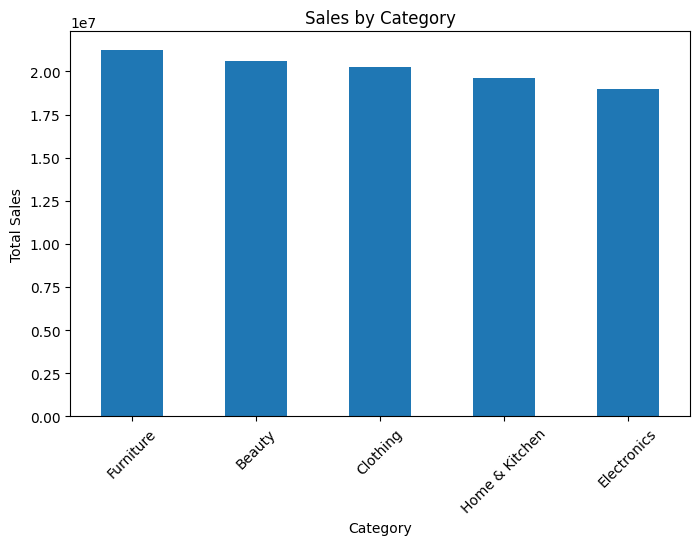

In [19]:
category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [20]:
top_products = df6.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)


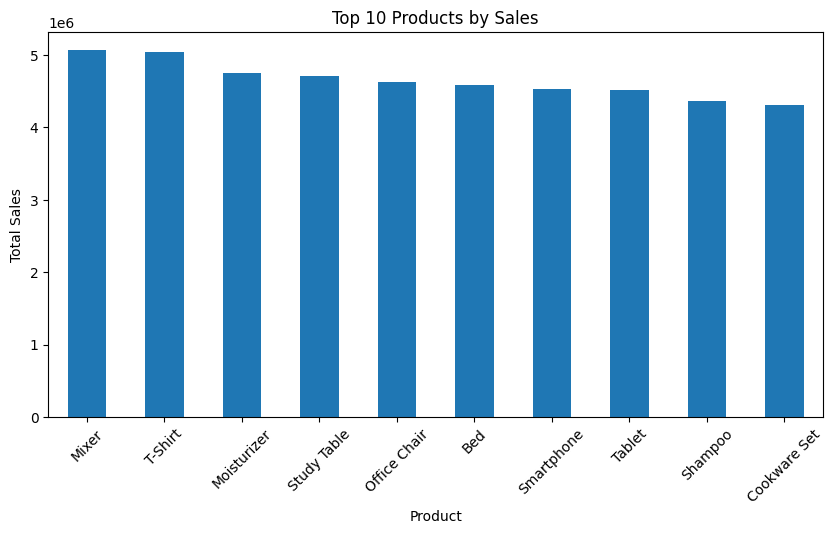

In [21]:
top_products.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [22]:
df6['Month'] = df6['Order_Date'].dt.to_period('M')

In [23]:
monthly_sales = df6.groupby('Month')['Sales'].sum()

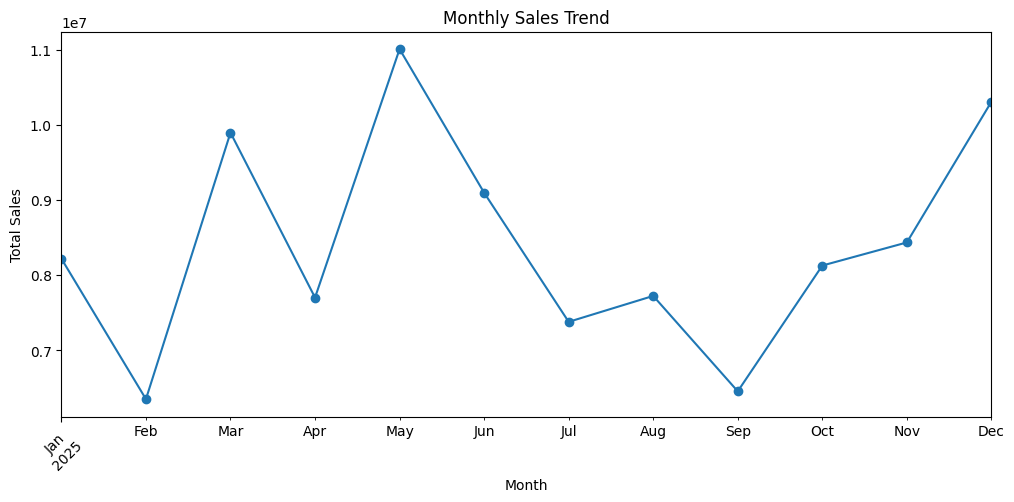

In [24]:
monthly_sales.plot(kind='line', marker='o', figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [25]:
customer_sales = df6.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)


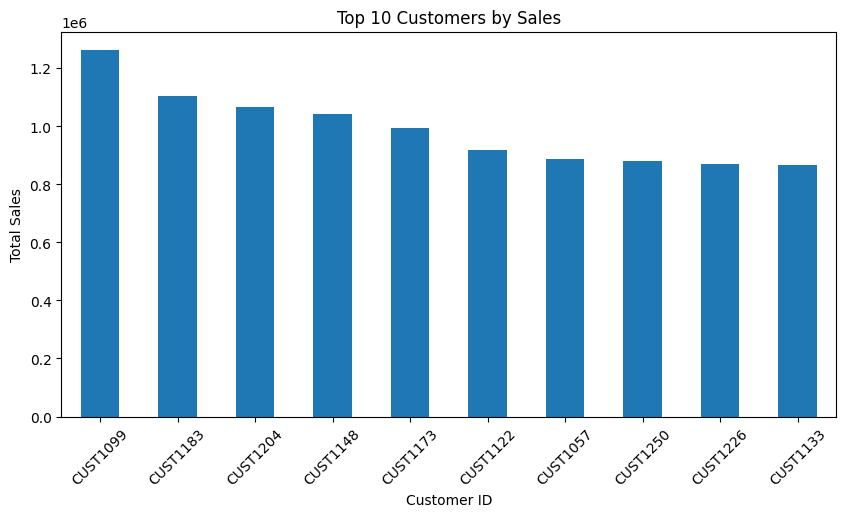

In [26]:
customer_sales.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [27]:
state_sales = df6.groupby('State')['Sales'].sum().sort_values(ascending=False)


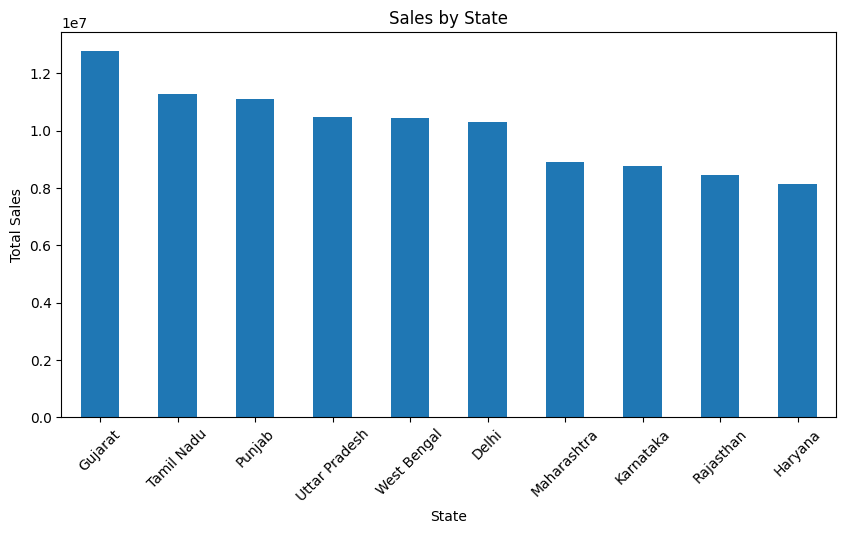

In [28]:
state_sales.plot(kind='bar', figsize=(10,5))
plt.title('Sales by State')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [29]:
city_sales = df6.groupby('City')['Sales'].sum().sort_values(ascending=False)


In [30]:
payment_count = df6['Payment_Mode'].value_counts()


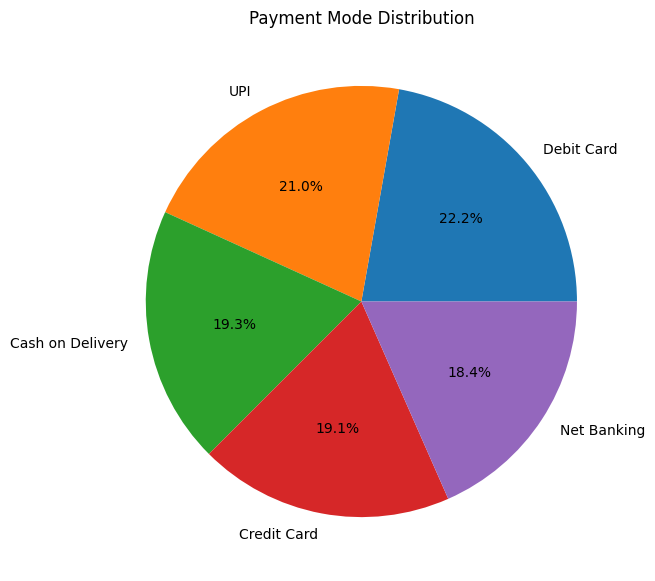

In [31]:
payment_count.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Payment Mode Distribution')
plt.ylabel('')
plt.show()

In [32]:
import sqlite3

conn = sqlite3.connect('ecommerce.db')

# Convert 'Month' column to string to avoid the SQLite 'Period' type binding error
if 'Month' in df6.columns:
    df6['Month'] = df6['Month'].astype(str)

df6.to_sql('Sales', conn, if_exists='replace', index=False)

1000

In [33]:
query = """
SELECT
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales;
"""

pd.read_sql(query, conn)

,Total_Sales,Total_Profit
0,100686782.6,15187101.12


In [34]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Total_Profit
0,Furniture,21257949.20,2853762.30
1,Beauty,20607899.25,3195093.10
2,Clothing,20237826.95,3094819.79
3,Home & Kitchen,19632120.80,3065483.98
4,Electronics,18950986.40,2977941.95


In [35]:
query = """
SELECT
    Product,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Product,Total_Sales
0,Mixer,5064598.15
1,T-Shirt,5040622.60
2,Moisturizer,4753104.15
3,Study Table,4708730.70
4,Office Chair,4624557.70
5,Bed,4589603.55
6,Smartphone,4529532.15
7,Tablet,4513938.10
8,Shampoo,4368418.30
9,Cookware Set,4312948.70


In [36]:
query = """
SELECT
    State,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY State
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,State,Total_Sales,Total_Profit
0,Gujarat,12798064.75,1732518.56
1,Tamil Nadu,11279203.65,1550991.89
2,Punjab,11094225.40,1791491.73
3,Uttar Pradesh,10492054.55,1648178.63
4,West Bengal,10436707.85,1677912.27
5,Delhi,10314351.90,1510267.80
6,Maharashtra,8920720.50,1379927.13
7,Karnataka,8756423.30,1374708.38
8,Rajasthan,8470841.80,1284435.97
9,Haryana,8124188.90,1236668.76


In [37]:
query = """
SELECT
    Payment_Mode,
    COUNT(*) AS Number_of_Orders,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Payment_Mode
ORDER BY Number_of_Orders DESC;
"""

pd.read_sql(query, conn)

,Payment_Mode,Number_of_Orders,Total_Sales
0,Debit Card,222,20938245.40
1,UPI,210,20973916.35
2,Cash on Delivery,193,19670201.20
3,Credit Card,191,20126951.10
4,Net Banking,184,18977468.55


In [38]:
query = """
SELECT
    Order_ID,
    Product,
    Category,
    Sales,
    Profit
FROM sales
WHERE Profit < 0
ORDER BY Profit ASC;
"""

pd.read_sql(query, conn)

,Order_ID,Product,Category,Sales,Profit


In [39]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
HAVING SUM(Sales) > 100000
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,Category,Total_Sales
0,Furniture,21257949.20
1,Beauty,20607899.25
2,Clothing,20237826.95
3,Home & Kitchen,19632120.80
4,Electronics,18950986.40


In [40]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin
FROM sales
GROUP BY Category
ORDER BY Profit_Margin DESC;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Total_Profit,Profit_Margin
0,Electronics,18950986.40,2977941.95,15.71
1,Home & Kitchen,19632120.80,3065483.98,15.61
2,Beauty,20607899.25,3195093.10,15.50
3,Clothing,20237826.95,3094819.79,15.29
4,Furniture,21257949.20,2853762.30,13.42


In [41]:
query = """
SELECT
    Customer_ID,
    COUNT(Order_ID) AS Total_Orders,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Customer_ID
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Customer_ID,Total_Orders,Total_Sales,Total_Profit
0,CUST1099,8,1262966.75,152740.64
1,CUST1183,8,1104812.25,189104.96
2,CUST1204,7,1065008.80,207003.49
3,CUST1148,7,1041660.90,150516.67
4,CUST1173,8,995062.85,132307.06
5,CUST1122,9,918187.40,146969.71
6,CUST1057,6,886916.00,60012.94
7,CUST1250,5,881574.00,160785.73
8,CUST1226,3,870404.00,146924.94
9,CUST1133,8,866446.90,118993.96


In [42]:
query = """
SELECT
    Discount,
    COUNT(Order_ID) AS Orders,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Discount
ORDER BY Discount;
"""

pd.read_sql(query, conn)

,Discount,Orders,Total_Sales,Total_Profit
0,0,147,16836139.0,2867144.80
1,5,178,19026943.9,3136024.51
2,10,170,16894229.4,2650572.22
3,15,165,15467715.2,2318293.96
4,20,171,16731841.6,2122001.08
5,25,169,15729913.5,2093064.55


In [43]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
HAVING SUM(Profit) < 0
ORDER BY Total_Profit;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Total_Profit


In [45]:
df6.describe()

,Order_Date,Quantity,Unit_Price,Sales,Discount,Profit
count,1000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2025-06-27 13:55:12,3.001000,38871.82800,100686.782600,12.710000,15187.101120
min,2025-01-01 00:00:00,1.000000,412.00000,350.200000,0.000000,0.380000
25%,2025-03-29 00:00:00,2.000000,19630.75000,34807.500000,5.000000,3872.352500
50%,2025-06-21 12:00:00,3.000000,37014.00000,74049.450000,15.000000,9468.515000
75%,2025-09-29 00:00:00,4.000000,59088.00000,150796.500000,20.000000,21602.432500
max,2025-12-31 00:00:00,5.000000,79955.00000,398160.000000,25.000000,94315.440000
std,NaN,1.441901,23264.24669,82474.106173,8.433684,16001.481309


In [47]:
df6[['Sales', 'Profit', 'Quantity', 'Discount']].describe()

,Sales,Profit,Quantity,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,100686.782600,15187.101120,3.001000,12.710000
std,82474.106173,16001.481309,1.441901,8.433684
min,350.200000,0.380000,1.000000,0.000000
25%,34807.500000,3872.352500,2.000000,5.000000
50%,74049.450000,9468.515000,3.000000,15.000000
75%,150796.500000,21602.432500,4.000000,20.000000
max,398160.000000,94315.440000,5.000000,25.000000


In [49]:
df6.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

,Sales,Profit
Category,,
Furniture,21257949.20,2853762.30
Beauty,20607899.25,3195093.10
Clothing,20237826.95,3094819.79
Home & Kitchen,19632120.80,3065483.98
Electronics,18950986.40,2977941.95


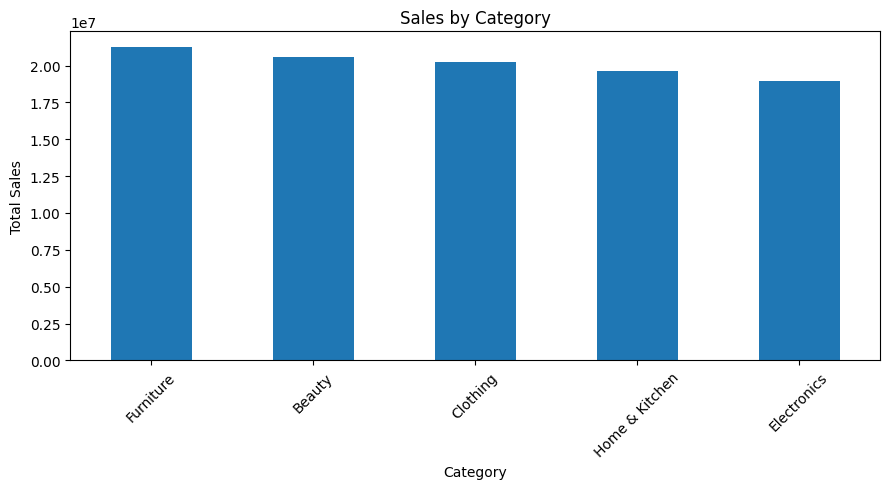

In [51]:
category_sales = df6.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', figsize=(9,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

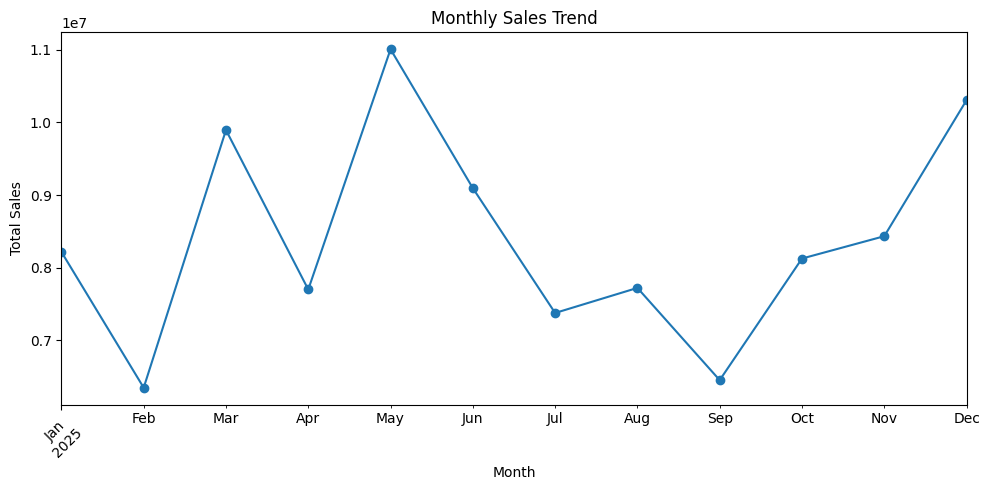

In [54]:
monthly_sales = df6.groupby(df6['Order_Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

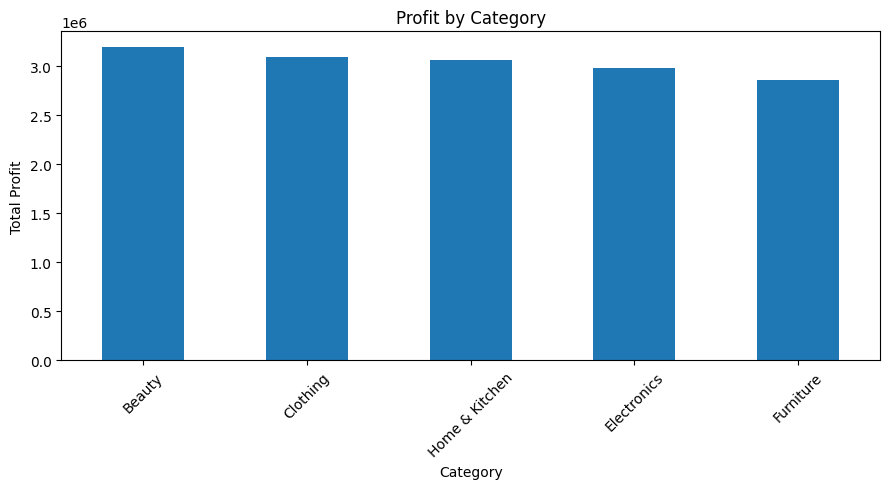

In [55]:
category_profit = df6.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit.plot(kind='bar', figsize=(9,5))
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()